In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(".."))
from scipy import stats
import pandas as pd
from v1.Utils import ReadTheCsv,ReadTheSpill,append_to_dict

# Load simulation outputs

In [2]:
files = os.listdir("../toy/output/")
#print(files)

outputs = ["toy/output/" + item for item in files if ".npz" in item]
print(outputs)

simulation_list = {}

for output in outputs:
    print(output)
    filename   = output.split("/")[2]
    tau        = output.split("_")[1].replace("s","")
    theta      = output.split("_")[3]
    axial      = output.split("_")[5].replace("mK","")
    transverse = output.split("_")[7].replace("mK","")
    append_to_dict(simulation_list, output, float(tau))
    append_to_dict(simulation_list, output, float(theta))
    append_to_dict(simulation_list, output, float(axial))
    append_to_dict(simulation_list, output, float(transverse))

['toy/output/tau_33.27s_theta_65_axial_2.28mK_transv_4.88mK_p_2.npz', 'toy/output/tau_27.02s_theta_38_axial_1.63mK_transv_3.39mK_p_2.npz', 'toy/output/tau_46.36s_theta_103_axial_7.58mK_transv_6.06mK_p_2.npz', 'toy/output/tau_22.63s_theta_163_axial_3.61mK_transv_1.59mK_p_2.npz', 'toy/output/tau_26.20s_theta_29_axial_2.62mK_transv_5.84mK_p_2.npz', 'toy/output/tau_36.66s_theta_169_axial_0.60mK_transv_6.08mK_p_2.npz', 'toy/output/tau_40.46s_theta_36_axial_2.07mK_transv_4.32mK_p_2.npz', 'toy/output/tau_21.66s_theta_179_axial_2.40mK_transv_3.17mK_p_2.npz', 'toy/output/tau_44.95s_theta_51_axial_3.13mK_transv_5.54mK_p_2.npz', 'toy/output/tau_35.50s_theta_65_axial_2.09mK_transv_4.98mK_p_2.npz', 'toy/output/tau_31.70s_theta_173_axial_1.93mK_transv_3.80mK_p_2.npz', 'toy/output/tau_31.70s_theta_61_axial_0.73mK_transv_3.90mK_p_2.npz', 'toy/output/tau_17.02s_theta_57_axial_1.54mK_transv_5.12mK_p_2.npz', 'toy/output/tau_30.45s_theta_43_axial_1.76mK_transv_3.91mK_p_2.npz', 'toy/output/tau_18.07s_theta

## Z cuts in 2025 dataset

In [2]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"

class Zcuts:
    def __init__(self,a,b, cuts):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a
        self.CutsType = cuts

ZCUTS = Zcuts(-415,-671, CutsType)

# Define the analysis functions for data and simulation

In [3]:
def analysis_function(output):
    file = np.load(output)
    R_array           = file['position']
    Time_Annihilation = file['Time']
    Time_Annihilation = Time_Annihilation[np.isfinite(Time_Annihilation)] # delete atoms that are still trapped, identified with 'nan'
    counts, edges     = np.histogram(Time_Annihilation, bins = 50, range = (0,398.1), density = False)
    return Time_Annihilation, counts, edges

def analysis_data(file, Zcuts):
    # read the file
    dataset = ReadTheCsv(file, "-1", Zcuts.zmin, Zcuts.zmax, ZCUTS.CutsType)
    # Three Segment Ramp Down
    start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill(file,"\"MBMF RampDown\"[0]")
    start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill(file,"\"MBMF RampDown\"[1]")
    start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill(file,"\"MBMF RampDown\"[2]")

    # print(f"{start_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown0[0] - start_mbmf_rampdown0[0]} ")
    # print(f"{start_mbmf_rampdown1[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown1[0] - start_mbmf_rampdown1[0]} ")
    # print(f"{start_mbmf_rampdown2[0] - start_mbmf_rampdown0[0]}; {stop_mbmf_rampdown2[0] - start_mbmf_rampdown2[0]} ")
    mask      = ((dataset[CutsType] == 1) & 
                (dataset["Z"] > ZCUTS.zmin) & 
                (dataset["Z"] < ZCUTS.zmax))
    mask_time = ((dataset["run time"] > start_mbmf_rampdown0[0]) & 
                 (dataset["run time"] < start_mbmf_rampdown0[0] + 398.1))

    Event_Distribution = dataset["run time"][mask & mask_time].to_numpy() - start_mbmf_rampdown0[0]
    X_distribution = dataset["X"][mask & mask_time].to_numpy()
    Y_distribution = dataset["Y"][mask & mask_time].to_numpy()
    Z_distribution = dataset["Z"][mask & mask_time].to_numpy()

    counts, edges = np.histogram(Event_Distribution, bins = 50, range = (0,398.1), density = False)
    
    return Event_Distribution, counts, edges

# Main Loop LR statitics and visualization

In [5]:
!ls

Comparison.ipynb  simulation_results.png


In [6]:
list_dataset = ["v1/ag14100/ag14100.vertex.csv",
                "v1/ag14106/ag14106.vertex.csv",
                "v1/ag14268/ag14268.vertex.csv",
                "v1/ag14286/ag14286.vertex.csv",
                "v1/ag14308/ag14308.vertex.csv"]

best_for_dataset = []
best_sim         = ""
stringa          = ""

dict_runs = {}
for dataset in list_dataset:
    Event_Distribution, counts_obs, edges_obs = analysis_data("../" + dataset, ZCUTS)
    append_to_dict(dict_runs, dataset, counts_obs)

best_LR     = 1e6
best_pvalue = 0.0

for file in outputs:
    LR_total    = 0
    Pvalue_tot  = 0
    Time_Simulation, counts_sim, edges_sim =  analysis_function("../" + file)
    
    for dataset in list_dataset:        
        counts_obs    = dict_runs[dataset][0]
        counts_sim    = counts_sim * counts_obs.sum() / counts_sim.sum()
        
        LR, pvalue_lr = stats.power_divergence(counts_obs, counts_sim, lambda_="log-likelihood")
        LR_total     += LR
        Pvalue_tot   += -2*np.log(pvalue_lr)
        
        print(f"LR statistic = {LR:.4}/{(len(counts_obs) - 1)}")
        print(f"p-value      = {pvalue_lr}")

    if not np.isfinite(LR_total):
        LR_total    = 9999999
    
    if(LR_total < best_LR):
        print(f'New Best Found: [{file} {LR_total}]  [{best_sim} {best_LR}]')
        best_sim    = file
        best_pvalue = Pvalue_tot/5
        best_LR     = LR_total
        stringa     = f"Best LR: {LR_total:.5}/245, pvalue = {best_pvalue:.4}"


    append_to_dict(simulation_list, file, LR_total)
    
    print(f"best pvalue {best_pvalue}")
    print(f"best LR {best_LR}")
    print("-"*16)

print(best_sim)
best_for_dataset.append((best_sim, stringa))

../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

../v1/ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

../v1/ag14106/ag14106.vertex.csv
   [23785.519-23796.721]=  11.202s |          "MBMF RampDown"[0]          |    1670       81       83       75     1093      800     2652      958     3535         8 

../v1/ag14106/ag14106.vertex.csv
   [23918.318-23929.520]=  11.202s |          "MBMF RampDown"[1]          |    1150       60       61       41      534      426     1250     1245     2562        

/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)
/tmp/ipykernel_51344/4059634069.py:30: RuntimeWarning: divide by zero encountered in log
  Pvalue_tot   += -2*np.log(pvalue_lr)
/home/adriano/.local/lib/python3.10/site-packages/scipy/stats/_stats_py.py:8025: RuntimeWarning: invalid value encountered in divide
  terms = 2.0 * special.xlogy(f_obs, f_obs / f_exp)


LR statistic = 161.4/49
p-value      = 6.3818317278818e-14
LR statistic = 150.1/49
p-value      = 3.389505682009257e-12
LR statistic = 117.0/49
p-value      = 1.7424666501874088e-07
LR statistic = 46.59/49
p-value      = 0.5712939431684022
LR statistic = 207.4/49
p-value      = 2.1812163646437748e-21
best pvalue 9.912097547782583
best LR 375.62854942811674
----------------
LR statistic = 152.5/49
p-value      = 1.517672583640364e-12
LR statistic = 127.1/49
p-value      = 7.468334760549206e-09
LR statistic = 107.3/49
p-value      = 3.0311321044502286e-06
LR statistic = 48.14/49
p-value      = 0.5080765315853636
LR statistic = 172.8/49
p-value      = 1.0475519482383997e-15
best pvalue 9.912097547782583
best LR 375.62854942811674
----------------
LR statistic = 112.2/49
p-value      = 7.307724240135381e-07
LR statistic = 131.5/49
p-value      = 1.7819518584724804e-09
LR statistic = 175.3/49
p-value      = 4.148893237030609e-16
LR statistic = 93.6/49
p-value      = 0.0001295010790107244
LR

In [7]:
for k, v in sorted(simulation_list.items(), key=lambda x: x[1][4])[:10]:
    print(f"{k}: LR = {v[4]}")

toy/output/tau_10.76s_theta_19_axial_3.08mK_transv_2.39mK_p_2.npz: LR = 343.14721080658154
toy/output/tau_9.49s_theta_17_axial_3.94mK_transv_2.41mK_p_2.npz: LR = 364.9411969479575
toy/output/tau_9.82s_theta_20_axial_3.20mK_transv_2.41mK_p_2.npz: LR = 375.62854942811674
toy/output/tau_15.73s_theta_24_axial_2.81mK_transv_2.76mK_p_2.npz: LR = 384.7617099564047
toy/output/tau_17.19s_theta_31_axial_2.84mK_transv_3.08mK_p_2.npz: LR = 392.4296012942739
toy/output/tau_14.22s_theta_21_axial_3.14mK_transv_2.39mK_p_2.npz: LR = 404.44666601134685
toy/output/tau_9.52s_theta_17_axial_3.83mK_transv_1.86mK_p_2.npz: LR = 409.0373677758015
toy/output/tau_21.05s_theta_36_axial_1.90mK_transv_3.70mK_p_2.npz: LR = 418.85959525098156
toy/output/tau_28.17s_theta_34_axial_3.29mK_transv_2.41mK_p_2.npz: LR = 425.8237399173298
toy/output/tau_24.44s_theta_35_axial_1.98mK_transv_4.29mK_p_2.npz: LR = 426.48421622863833


[('toy/output/tau_10.76s_theta_19_axial_3.08mK_transv_2.39mK_p_2.npz', 'Best LR: 343.15/245, pvalue = 8.149')]
../v1/ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

../v1/ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

../v1/ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

../v1/ag14106/ag14106.vertex.csv
   [23785.519-23796.721]=  11.202s |          "MBMF RampDown"[0]          |    1670       81       83       75     1093      800     2652      958     3535         8 

../v1/ag14106/ag14106.vertex.csv
   [23918.318-23929.520]=  11.202s |          "MBMF 

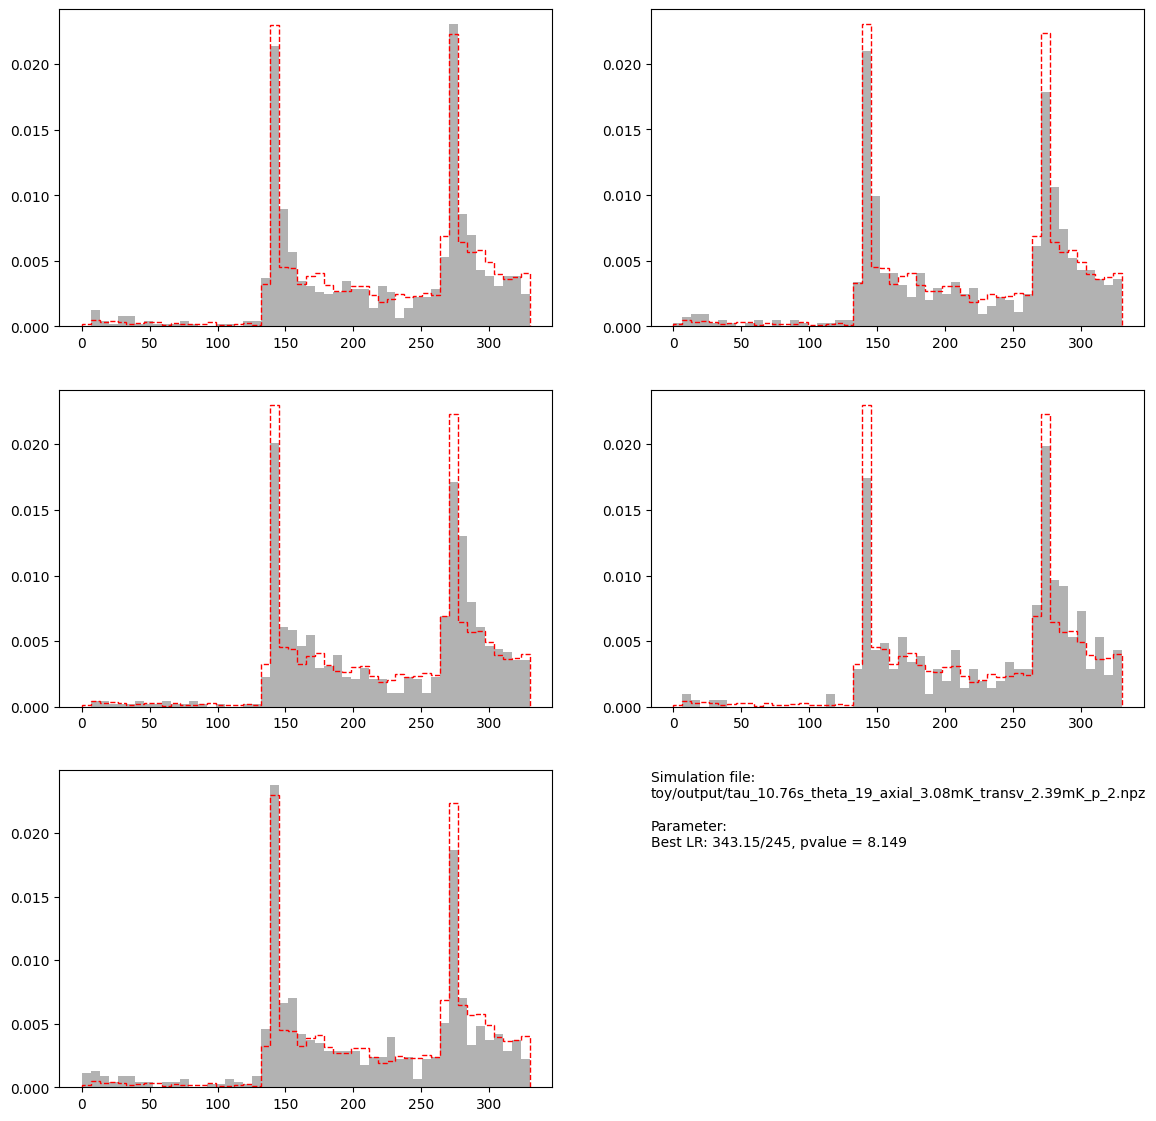

In [8]:
plt.figure(0, figsize=(14,14))

print(best_for_dataset)

i = 1
for dataset in list_dataset:
    simulation = best_for_dataset
    ax         = plt.subplot(3, 2, i)
    i += 1

    Time_Simulation, counts, edges = analysis_function("../" + str(simulation[0][0]))
    Event_Distribution, counts, edges = analysis_data("../" + dataset, ZCUTS)

    ax.hist(Event_Distribution, bins=50, range=(0,330), density=True,
            color="black", alpha=.3)

    ax.hist(Time_Simulation, bins=50, range=(0,330), density=True,
            linestyle="--", histtype="step", color="red")

# ---- ultimo subplot SOLO TESTO ----
ax_text = plt.subplot(3, 2, 6)
ax_text.axis("off")   # niente assi

text = (
    f"Simulation file:\n"
    f"{simulation[0][0]}\n\n"
    f"Parameter:\n"
    f"{simulation[0][1]}"
)

ax_text.text(
    0.0, 1.0, text,
    transform=ax_text.transAxes,
    fontsize=10,
    verticalalignment="top"
)

plt.savefig("simulation_results.png", bbox_inches="tight")

# heatmap

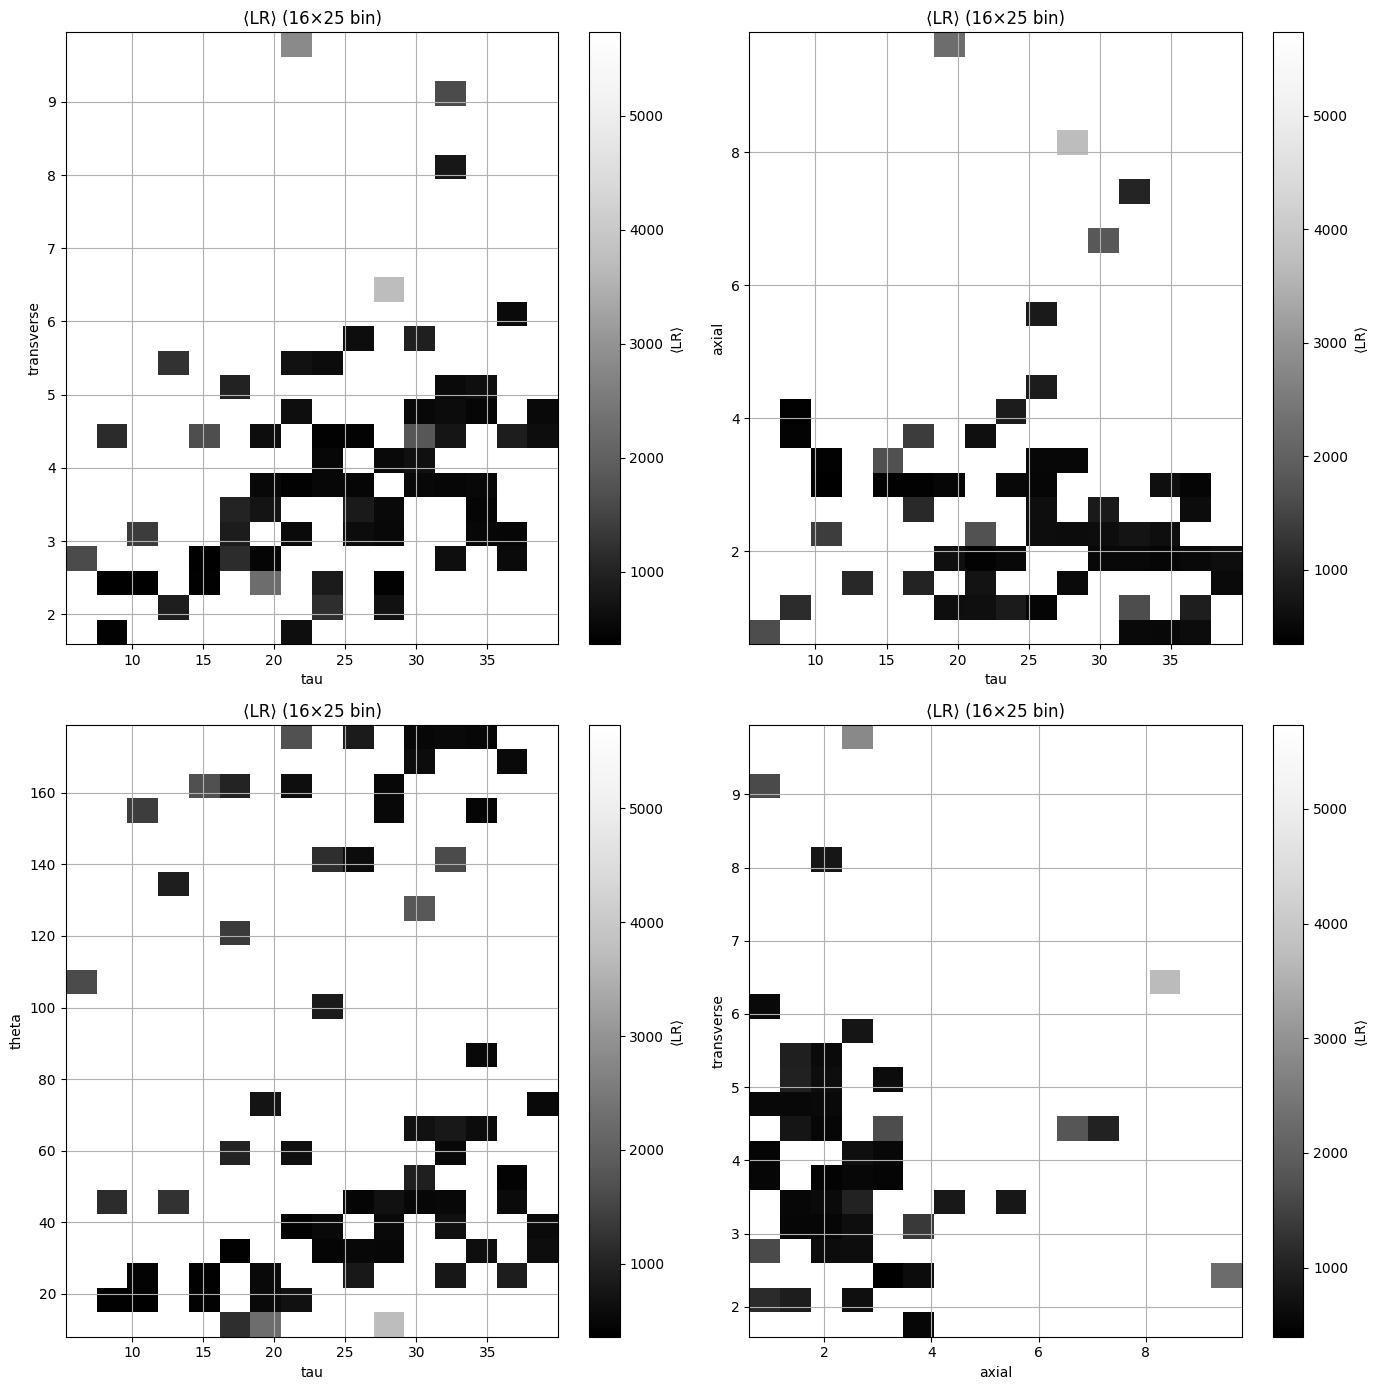

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# simulation_list = {
#     "file1.npz": [tau1, theta1, axial1, transverse1, LR1],
#     "file2.npz": [tau2, theta2, axial2, transverse2, LR2],
#     ...
# }

df = pd.DataFrame.from_dict(simulation_list, orient='index',
                            columns=["tau", "theta", "axial", "transverse", "LR"])


# Filtra il DataFrame per tau tra 0 e 40
df = df[(df["tau"] >= 0) & (df["tau"] <= 40) & (df["LR"] <= 99999)]

# Crea figura con 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Lista delle coppie di parametri da plottare
param_pairs = [
    ("tau", "transverse"),
    ("tau", "axial"),
    ("tau", "theta"),
    ("axial",   "transverse")
]

for i, (x_param, y_param) in enumerate(param_pairs):
    ax = axes[i // 2, i % 2]

    # estrai dati e rimuovi NaN
    mask = (
        np.isfinite(df[x_param]) &
        np.isfinite(df[y_param]) &
        np.isfinite(df["LR"])
    )

    x = df.loc[mask, x_param].values
    y = df.loc[mask, y_param].values
    z = df.loc[mask, "LR"].values

    # range fissi
    x_range = (x.min(), x.max())
    y_range = (y.min(), y.max())

    # binning
    LR_sum, xedges, yedges = np.histogram2d(
        x, y,
        bins=[16, 25],
        range=[x_range, y_range],
        weights=z
    )

    counts, _, _ = np.histogram2d(
        x, y,
        bins=[16, 25],
        range=[x_range, y_range]
    )

    # FIX: inizializza LR_mean
    LR_mean = np.full_like(LR_sum, np.nan, dtype=float)
    
    LR_mean[counts != 0] = LR_sum[counts != 0] / counts[counts != 0] #print(LR_mean)
    pcm = ax.pcolormesh(
        xedges,
        yedges,
        LR_mean.T,
        cmap="Greys_r",
        shading="auto"
    )

    ax.set_xlabel(x_param)
    ax.set_ylabel(y_param)
    ax.set_title("⟨LR⟩ (16×25 bin)")
    ax.grid(True)

    fig.colorbar(pcm, ax=ax, label="⟨LR⟩")

#axes[1, 1].axis("off")
plt.tight_layout()
plt.show()


# ===> ANALYZE SCURVE

In [4]:
from toy.UTILS import Zmin, Zmax, Zmid, zacceptance_min, zacceptance_max

/home/adriano/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [5]:
Tramp1     = 11.2
wait_ramp1 = 121.5 + Tramp1

Tramp2     = 11.2 + wait_ramp1
wait_ramp2 = 121.5 + Tramp2

Tramp3     = 11.2 + wait_ramp2
wait_ramp3 = 121.5 + Tramp3

In [6]:
def get_annihilations(output, bias):
    "output: simulation path to load"
    
    file = np.load(output)
    R_array           = file['position']
    Time_Annihilation = file['Time']

    # mask the particles still trapped at the end of the release
    mask       = np.isfinite(Time_Annihilation)
    Z_position = R_array[mask,2]
    #print(len(Z_position))
    Time_Annihilation = Time_Annihilation[mask]  

    # get the Annihilations
    Nup   = (Z_position >= zacceptance_max - 0.001).sum()
    Ndown = (Z_position <= zacceptance_min + 0.001).sum()
    
    # Compute the asymmetry
    A,  A0,   A1,  A2 = 0,0,0,0
    dA, dA0, dA1, dA2 = 0,0,0,0
    
    if((Nup + Ndown) > 0):
        A = (Ndown - Nup) / (Nup + Ndown)
        dA = np.sqrt(abs(1 - A**2)/(Nup + Ndown))
    else:
        dResult = np.nan

    # SEGMENT 1 
    Nup   = ((Z_position >= zacceptance_max - 0.001) & (Time_Annihilation > 0) & (Time_Annihilation < Tramp1)).sum()
    Ndown = ((Z_position <= zacceptance_min + 0.001) & (Time_Annihilation > 0) & (Time_Annihilation < Tramp1)).sum()

    print(f"{bias}, segmet 1: {Nup + Ndown}")
    
    if((Nup + Ndown) > 0):
        A0 = (Ndown - Nup) / (Nup + Ndown)
        dA0 = np.sqrt(abs(1 - A**2)/(Nup + Ndown))
    else:
        A0  = np.nan
        dA0 = np.nan

    Nup   = ((Z_position >= zacceptance_max - 0.001) & (Time_Annihilation > Tramp1) & (Time_Annihilation < wait_ramp1)).sum()
    Ndown = ((Z_position <= zacceptance_min + 0.001) & (Time_Annihilation > Tramp1) & (Time_Annihilation < wait_ramp1)).sum()

    print(f"{bias}, segmet 1: {Nup + Ndown}")
    
    if((Nup + Ndown) > 0):
        A0b = (Ndown - Nup) / (Nup + Ndown)
        dA0b = np.sqrt(abs(1 - A**2)/(Nup + Ndown))
    else:
        A0b  = np.nan
        dA0b = np.nan
    
    
    # SEGMENT 2
    Nup   = ((Z_position >= zacceptance_max  - 0.001) & (Time_Annihilation > wait_ramp1) & (Time_Annihilation < Tramp2)).sum()
    Ndown = ((Z_position <= zacceptance_min  + 0.001) & (Time_Annihilation > wait_ramp1) & (Time_Annihilation < Tramp2)).sum()

    print(f"{bias}, segmet 2: {Nup + Ndown}")
    
    if((Nup + Ndown) > 0):
        A1 = (Ndown - Nup) / (Nup + Ndown)
        dA1 = np.sqrt(abs(1 - A**2)/(Nup + Ndown))
    else:
        A1  = np.nan
        dA1 = np.nan

    Nup   = ((Z_position >= zacceptance_max  - 0.001) & (Time_Annihilation > Tramp2) & (Time_Annihilation < wait_ramp2)).sum()
    Ndown = ((Z_position <= zacceptance_min  + 0.001) & (Time_Annihilation > Tramp2) & (Time_Annihilation < wait_ramp2)).sum()

    print(f"{bias}, segmet 2: {Nup + Ndown}")
    
    if((Nup + Ndown) > 0):
        A1b = (Ndown - Nup) / (Nup + Ndown)
        dA1b = np.sqrt(abs(1 - A**2)/(Nup + Ndown))
    else:
        A1b  = np.nan
        dA1b = np.nan

    # SEGMENT 3
    Nup   = ((Z_position >= zacceptance_max - 0.001) & (Time_Annihilation > wait_ramp2) & (Time_Annihilation < Tramp3)).sum()
    Ndown = ((Z_position <= zacceptance_min + 0.001) & (Time_Annihilation > wait_ramp2) & (Time_Annihilation < Tramp3)).sum()

    print(f"{bias}, segmet 3: {Nup + Ndown}")
    
    if((Nup + Ndown) > 0):
        A2 = (Ndown - Nup) / (Nup + Ndown)
        dA2 = np.sqrt(abs(1 - A**2)/(Nup + Ndown))
    else:
        A2  = np.nan
        dA2 = np.nan

    Nup   = ((Z_position >= zacceptance_max - 0.001) & (Time_Annihilation > Tramp3)).sum()
    Ndown = ((Z_position <= zacceptance_min + 0.001) & (Time_Annihilation > Tramp3)).sum()

    print(f"{bias}, segmet 3: {Nup + Ndown}")
    
    if((Nup + Ndown) > 0):
        A2b = (Ndown - Nup) / (Nup + Ndown)
        dA2b = np.sqrt(abs(1 - A**2)/(Nup + Ndown))
    else:
        A2b  = np.nan
        dA2b = np.nan
    
    return [A0,A1,A2,A, A0b, A1b, A2b], [dA0,dA1,dA2,dA,dA0b,dA1b,dA2b]

# Make Plot Nicer
def plotter_nicer():
    plt.ylabel(r"S = $\frac{N_{\downarrow} - N_{\uparrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
    plt.xlabel("bias", loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
    plt.ylim(-1.1,1.1)
    #plt.xlim(-3, 3)
    
    plt.axhline(0.0, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.75)
    #plt.text(-2.9, 0.005, "balance escape 0.0", color = "red")
    plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.75)
    #plt.axvline(-2,   linestyle = "-",  color = "black",  linewidth = 0.75)
    plt.axvline(-1,  linestyle = "-", color = "maroon", linewidth = 0.75)
    plt.text( -1. + 0.02, 0.65, "-1.0g bias", rotation = 90, color = "maroon")

Outputs files: 
 ['../toy/output/output_scurve/output_0p05g.npz.npz', '../toy/output/output_scurve/output_0g.npz.npz', '../toy/output/output_scurve/output_-0p1g.npz.npz', '../toy/output/output_scurve/output_-1p25g.npz.npz', '../toy/output/output_scurve/output_-0p5g.npz.npz', '../toy/output/output_scurve/output_-0p05g.npz.npz', '../toy/output/output_scurve/output_0p75g.npz.npz', '../toy/output/output_scurve/output_-0p375g.npz.npz', '../toy/output/output_scurve/output_-0p3g.npz.npz', '../toy/output/output_scurve/output_0p1g.npz.npz', '../toy/output/output_scurve/output_-0p25g.npz.npz', '../toy/output/output_scurve/output_-1g.npz.npz', '../toy/output/output_scurve/output_1p25g.npz.npz', '../toy/output/output_scurve/output_0p5g.npz.npz', '../toy/output/output_scurve/output_0p25g.npz.npz', '../toy/output/output_scurve/output_-0p75g.npz.npz']
--------------------
0p05g, segmet 1: 9
0p05g, segmet 1: 73
0p05g, segmet 2: 335
0p05g, segmet 2: 825
0p05g, segmet 3: 404
0p05g, segmet 3: 1064
0p05g 

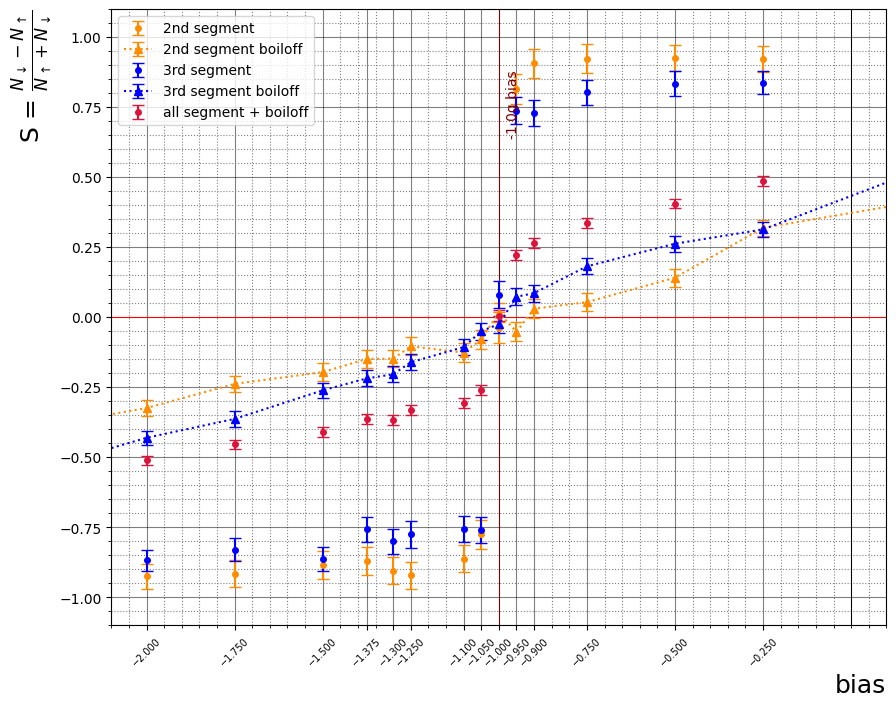

In [9]:
files = os.listdir("../toy/output/output_scurve")

outputs = ["../toy/output/output_scurve/" + item for item in files if ".npz" in item]
print("Outputs files: \n", outputs)

simulation_dataset = {}

A0,   A1,  A2, At  = [],[],[],[]
A0b,   A1b,  A2b  = [],[],[]
dA0, dA1, dA2, dAt = [],[],[],[]
dA0b, dA1b, dA2b = [],[],[]

biases = []

for output in outputs:
    print("-"*20)
    bias = output.split("_")[2].replace(".npz","") # get the bias
    A, dA = get_annihilations(output, bias)

    A0.append(A[0])
    A1.append(A[1])
    A2.append(A[2])
    At.append(A[3])
    A0b.append(A[4])
    A1b.append(A[5])
    A2b.append(A[6])
    
    dA0.append(dA[0])
    dA1.append(dA[1])
    dA2.append(dA[2])
    dAt.append(dA[3])
    dA0b.append(dA[4])
    dA1b.append(dA[5])
    dA2b.append(dA[6])

    print(bias, f"{A[0]:.2}",  f"{dA[0]:.2f}")
    print(bias, f"{A[1]:.2f}", f"{dA[1]:.2f}")
    print(bias, f"{A[2]:.2f}", f"{dA[2]:.2f}")

    biases.append( float( bias.replace("p",".").replace("g","") ))

biases = np.array(biases)
#print(biases)

At = np.array(At)
dAt = np.array(dAt)
A0 = np.array(A0)
A1 = np.array(A1)
A2 = np.array(A2)
A0b = np.array(A0)
A1b = np.array(A1b)
A2b = np.array(A2b)
A0 = np.array(A0)
dA1 = np.array(dA1)
dA2 = np.array(dA2)
dA0b = np.array(dA0)
dA1b = np.array(dA1b)
dA2b = np.array(dA2b)

plt.figure(1, figsize = (10,8))
plotter_nicer()

idx = np.argsort(biases)


#plt.errorbar(biases, A0, marker = "s", linestyle = "", label = "1st segment")
plt.errorbar(biases[idx]-1, A1[idx],dA1[idx], marker = ".", linestyle = "", markersize = 8,color = "darkorange", capsize = 4, label = "2nd segment")
plt.errorbar(biases[idx]-1, A1b[idx],dA1b[idx], marker = "^", linestyle = "dotted", markersize = 6,color = "darkorange", capsize = 4, label = "2nd segment boiloff")
plt.errorbar(biases[idx]-1, A2[idx],dA2[idx], marker = ".", linestyle = "", markersize = 8, color = "blue", capsize = 4, label = "3rd segment")
plt.errorbar(biases[idx]-1, A2b[idx],dA2b[idx], marker = "^", linestyle = "dotted", markersize = 6,  color = "blue",capsize = 4, label = "3rd segment boiloff")


plt.errorbar(biases[idx]-1, At[idx],dAt[idx], marker = ".", linestyle = "", markersize = 8, capsize = 4, label = "all segment + boiloff", color = "crimson")
plt.xticks(biases[idx]-1, rotation = 45, fontsize = 7)
plt.xlim(-2.1,0.1)

plt.legend()
plt.savefig("Simulated_Scurve.png", bbox_inches = 'tight')